https://unit8co.github.io/darts/examples/13-TFT-examples.html
!pip uninstall -y coverage pytest-cov
!pip install "coverage>=7.4" "pytest-cov>=4.1"

In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# use darts plotting style
from darts import set_option

set_option("plotting.use_darts_style", True)

In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.datasets import AirPassengersDataset, IceCreamHeaterDataset
from darts.metrics import mape
from darts.models import TFTModel
from darts.utils.likelihood_models.torch import QuantileRegression
from darts.utils.statistics import check_seasonality, plot_acf
from darts.utils.timeseries_generation import datetime_attribute_timeseries

from pytorch_lightning.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

In [27]:
# before starting, we define some constants
num_samples = 200

figsize = (9, 6)
lowest_q, low_q, high_q, highest_q = 0.01, 0.1, 0.9, 0.99
label_q_outer = f"{int(lowest_q * 100)}-{int(highest_q * 100)}th percentiles"
label_q_inner = f"{int(low_q * 100)}-{int(high_q * 100)}th percentiles"

In [52]:
df = pd.read_csv("../data/processed/processed_data_pre_model.csv") 

# Cleaning columns
# Dropping lags, dupicate columns
df = df[['date'
                      , 'county_fips'
                      , 'county_name_x'
                      , 'median_listing_price_x' #taking median to control for outliers
                      , 'active_listing_count'
                      , 'median_days_on_market_x'
                      , 'new_listing_count'
                      , 'price_increased_count'
                      , 'price_increased_share'
                      , 'price_reduced_count'
                      , 'price_reduced_share'
                      , 'pending_listing_count'
                      #, 'median_listing_price_per_square_foot' #leaking target
                      , 'median_square_feet'
                      #, 'average_listing_price' #leaking target
                      , 'total_listing_count'
                      , 'pending_ratio'
                      , 'hotness_rank'
                      , 'hotness_score'
                      , 'supply_score'
                      , 'demand_score'
                      , 'median_dom_vs_us'
                      , 'page_view_count_per_property_vs_us'
                      #, 'median_listing_price_vs_us' #leaking target
                      , 'city'
                      , 'state'# how does this work, data quality?
                      , 'Earnings' # these are repeated?
                      , 'Unemployment_Rate' # these are repeated?
                      , 'Investor Purchases'
                      , 'Investor Market Share'
                      , 'U.S. 30 year FRM'
                      , '30 year fees & points'
                      , 'U.S. 15 year FRM'
                      , '15 year fees & points'
                      , 'U.S. 5/1 ARM'
                      , '5/1 year fees & points'
                      , 'U.S. 5/1 ARM margin'
                      , '30 year FRM / 5/1 ARM spread'
                      , 'highest_category' #Florida only
                      ]]

df.drop(columns=['hotness_rank' # dropping, rank and score are 100% correlated
, 'highest_category' #Florida only, dropping for now
, 'U.S. 15 year FRM' # dropping, highly correlated with 30 year 
, 'county_name_x' #county fips is numeric version
, 'city' # dupicative with fips
#,'state' # dupicative with fips
], inplace=True)

# Filter to Florida, keep at COUNTY level (no aggregation to state)
df = df[df['state'].isin(['fl'])]

# Drop rows where median_listing_price_x is NA
df = df.dropna(subset=['median_listing_price_x'])

# Ensure date is datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['county_fips', 'date'])

In [53]:
# Build multi-series TFT at county level
from pytorch_lightning.callbacks import EarlyStopping

future_cov_cols = ['U.S. 30 year FRM']
past_cov_cols = [
    'median_days_on_market_x', 'demand_score', 'supply_score',
    'active_listing_count', 'pending_ratio', 'hotness_score',
    'new_listing_count', 'Unemployment_Rate', 'Earnings'
]
all_cov_cols = future_cov_cols + past_cov_cols

training_cutoff = pd.Timestamp("2023-07-01")

# Lists for multi-series TFT
train_series_list = []
val_series_list = []
full_series_list = []
future_cov_list = []
past_cov_list = []

# Per-county scalers and metadata for inverse transforms later
county_results = {}

for fips, df_county in df.groupby('county_fips'):
    df_county = df_county.sort_values('date').copy()
    df_county[all_cov_cols] = df_county[all_cov_cols].bfill().ffill()
    
    # Skip counties with remaining NaNs in covariates
    if df_county[all_cov_cols].isna().any().any():
        print(f"Skipping county {fips} due to NaN in covariates")
        continue
    
    # Target series
    series = TimeSeries.from_dataframe(
        df_county, time_col='date', value_cols='median_listing_price_x', freq='MS'
    )
    
    # Static covariate: county_fips as numeric identifier for the model
    series = series.with_static_covariates(pd.DataFrame({'county_fips': [fips]}))
    
    # Future covariates (known ahead: mortgage rates + time features)
    fut_cov = TimeSeries.from_dataframe(
        df_county, time_col='date', value_cols=future_cov_cols, freq='MS'
    )
    fut_cov = fut_cov.stack(datetime_attribute_timeseries(series, attribute="year", one_hot=False))
    fut_cov = fut_cov.stack(datetime_attribute_timeseries(series, attribute="month", one_hot=False))
    fut_cov = fut_cov.stack(
        TimeSeries.from_times_and_values(
            times=series.time_index,
            values=np.arange(len(series)),
            columns=["linear_increase"],
        )
    )
    fut_cov = fut_cov.astype(np.float32)
    
    # Past covariates (only historical)
    past_cov = TimeSeries.from_dataframe(
        df_county, time_col='date', value_cols=past_cov_cols, freq='MS'
    )
    past_cov = past_cov.astype(np.float32)
    
    # Split
    train, val = series.split_after(training_cutoff)
    
    # Skip counties with too-short validation
    if len(val) < 2:
        print(f"Skipping county {fips}: val length {len(val)}")
        continue
    
    # Normalize per-county
    scaler_target = Scaler()
    train_transformed = scaler_target.fit_transform(train)
    val_transformed = scaler_target.transform(val)
    series_transformed = scaler_target.transform(series)
    
    scaler_future = Scaler()
    fut_train, _ = fut_cov.split_after(training_cutoff)
    scaler_future.fit(fut_train)
    fut_cov_transformed = scaler_future.transform(fut_cov)
    
    scaler_past = Scaler()
    past_train, _ = past_cov.split_after(training_cutoff)
    scaler_past.fit(past_train)
    past_cov_transformed = scaler_past.transform(past_cov)
    
    # Append to multi-series lists
    train_series_list.append(train_transformed)
    val_series_list.append(val_transformed)
    full_series_list.append(series_transformed)
    future_cov_list.append(fut_cov_transformed)
    past_cov_list.append(past_cov_transformed)
    
    # Store per-county info for later evaluation
    county_results[fips] = {
        'series_transformed': series_transformed,
        'train_transformed': train_transformed,
        'val_transformed': val_transformed,
        'future_cov_transformed': fut_cov_transformed,
        'past_cov_transformed': past_cov_transformed,
        'scaler_target': scaler_target,
        'train': train,
        'val': val,
    }

print(f"\nMulti-series TFT: {len(train_series_list)} county series prepared")
print(f"Training samples per county: ~{len(train_series_list[0])} months")

# --- Fit single TFT model on ALL counties simultaneously ---
quantiles = [
    0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,
]
input_chunk_length = 12
forecast_horizon = 12

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, min_delta=0.001, mode="min"
)

my_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=forecast_horizon,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=32,
    n_epochs=300,
    add_relative_index=True,
    add_encoders=None,
    likelihood=QuantileRegression(quantiles=quantiles),
    random_state=1,
    pl_trainer_kwargs={"callbacks": [early_stop]},
)

# Train on lists of series (multi-series)
my_model.fit(
    train_series_list,
    future_covariates=future_cov_list,
    past_covariates=past_cov_list,
    val_series=val_series_list,
    val_future_covariates=future_cov_list,
    val_past_covariates=past_cov_list,
    verbose=True,
)

print("Multi-series TFT training complete.")

Skipping county 12013 due to NaN in covariates
Skipping county 12029 due to NaN in covariates
Skipping county 12037 due to NaN in covariates
Skipping county 12041 due to NaN in covariates
Skipping county 12043 due to NaN in covariates
Skipping county 12045 due to NaN in covariates
Skipping county 12047 due to NaN in covariates
Skipping county 12049 due to NaN in covariates
Skipping county 12059 due to NaN in covariates
Skipping county 12065 due to NaN in covariates
Skipping county 12067 due to NaN in covariates
Skipping county 12077 due to NaN in covariates
Skipping county 12079 due to NaN in covariates
Skipping county 12123 due to NaN in covariates
Skipping county 12125 due to NaN in covariates
Skipping county 12133 due to NaN in covariates

Multi-series TFT: 51 county series prepared
Training samples per county: ~85 months


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │  1.6 K │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 28.1 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │  8.8 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │ 66.6 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │  1.1 K │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 313 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 313 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 453                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Multi-series TFT training complete.


Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

County-level MAPE across 51 counties:
  Mean:   20.00%
  Median: 12.61%
  Min:    3.63%
  Max:    79.98%

State-level (FL) aggregated MAPE: 5.60%


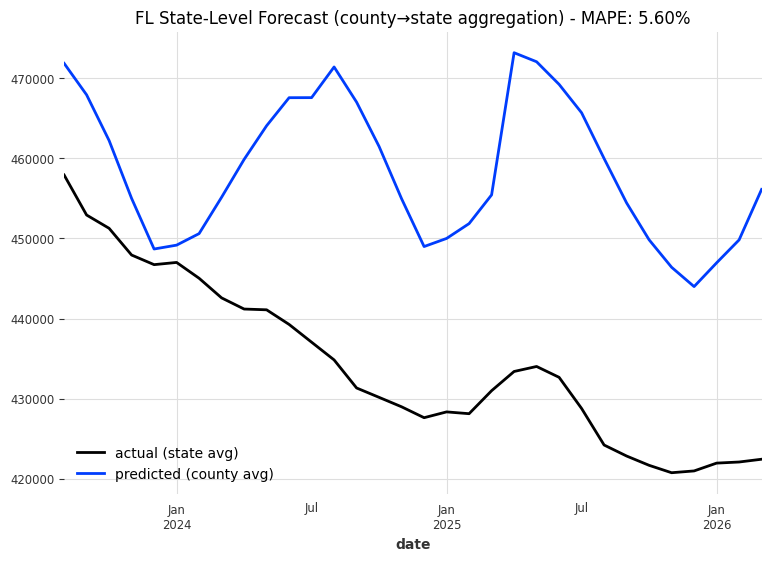

In [61]:
# Evaluate: predict for each county, compute per-county MAPE, then aggregate to state level
county_preds = {}
county_mapes = {}

for i, (fips, data) in enumerate(county_results.items()):
    pred = my_model.predict(
        n=len(data['val_transformed']),
        series=data['train_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        num_samples=num_samples,
    )
    county_preds[fips] = pred
    county_mapes[fips] = mape(data['val_transformed'], pred)

# Summary stats
mape_values = list(county_mapes.values())
print(f"County-level MAPE across {len(mape_values)} counties:")
print(f"  Mean:   {np.mean(mape_values):.2f}%")
print(f"  Median: {np.median(mape_values):.2f}%")
print(f"  Min:    {np.min(mape_values):.2f}%")
print(f"  Max:    {np.max(mape_values):.2f}%")

# --- Aggregate county predictions to state level ---
# Inverse-transform each county's prediction and actual, then average across counties
from functools import reduce

state_pred_dfs = []
state_actual_dfs = []

for fips, data in county_results.items():
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(county_preds[fips])
    val_inv = scaler.inverse_transform(data['val_transformed'])
    
    # Convert to pandas for averaging
    pred_df = pred_inv.quantile(0.5).to_dataframe()  # median forecast
    pred_df.columns = [fips]
    state_pred_dfs.append(pred_df)
    
    val_df = val_inv.to_dataframe()
    val_df.columns = [fips]
    state_actual_dfs.append(val_df)

# Average across all counties to get state-level
state_pred_df = pd.concat(state_pred_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')
state_actual_df = pd.concat(state_actual_dfs, axis=1).mean(axis=1).to_frame('median_listing_price_x')

state_pred_ts = TimeSeries.from_dataframe(state_pred_df, freq='MS')
state_actual_ts = TimeSeries.from_dataframe(state_actual_df, freq='MS')

state_mape = mape(state_actual_ts, state_pred_ts)
print(f"\nState-level (FL) aggregated MAPE: {state_mape:.2f}%")

# Plot state-level result
plt.figure(figsize=figsize)
state_actual_ts.plot(label="actual (state avg)")
state_pred_ts.plot(label="predicted (county avg)")
plt.title(f"FL State-Level Forecast (county→state aggregation) - MAPE: {state_mape:.2f}%")
plt.legend()

Text(0.5, 1.02, 'Sample County-Level Forecasts')

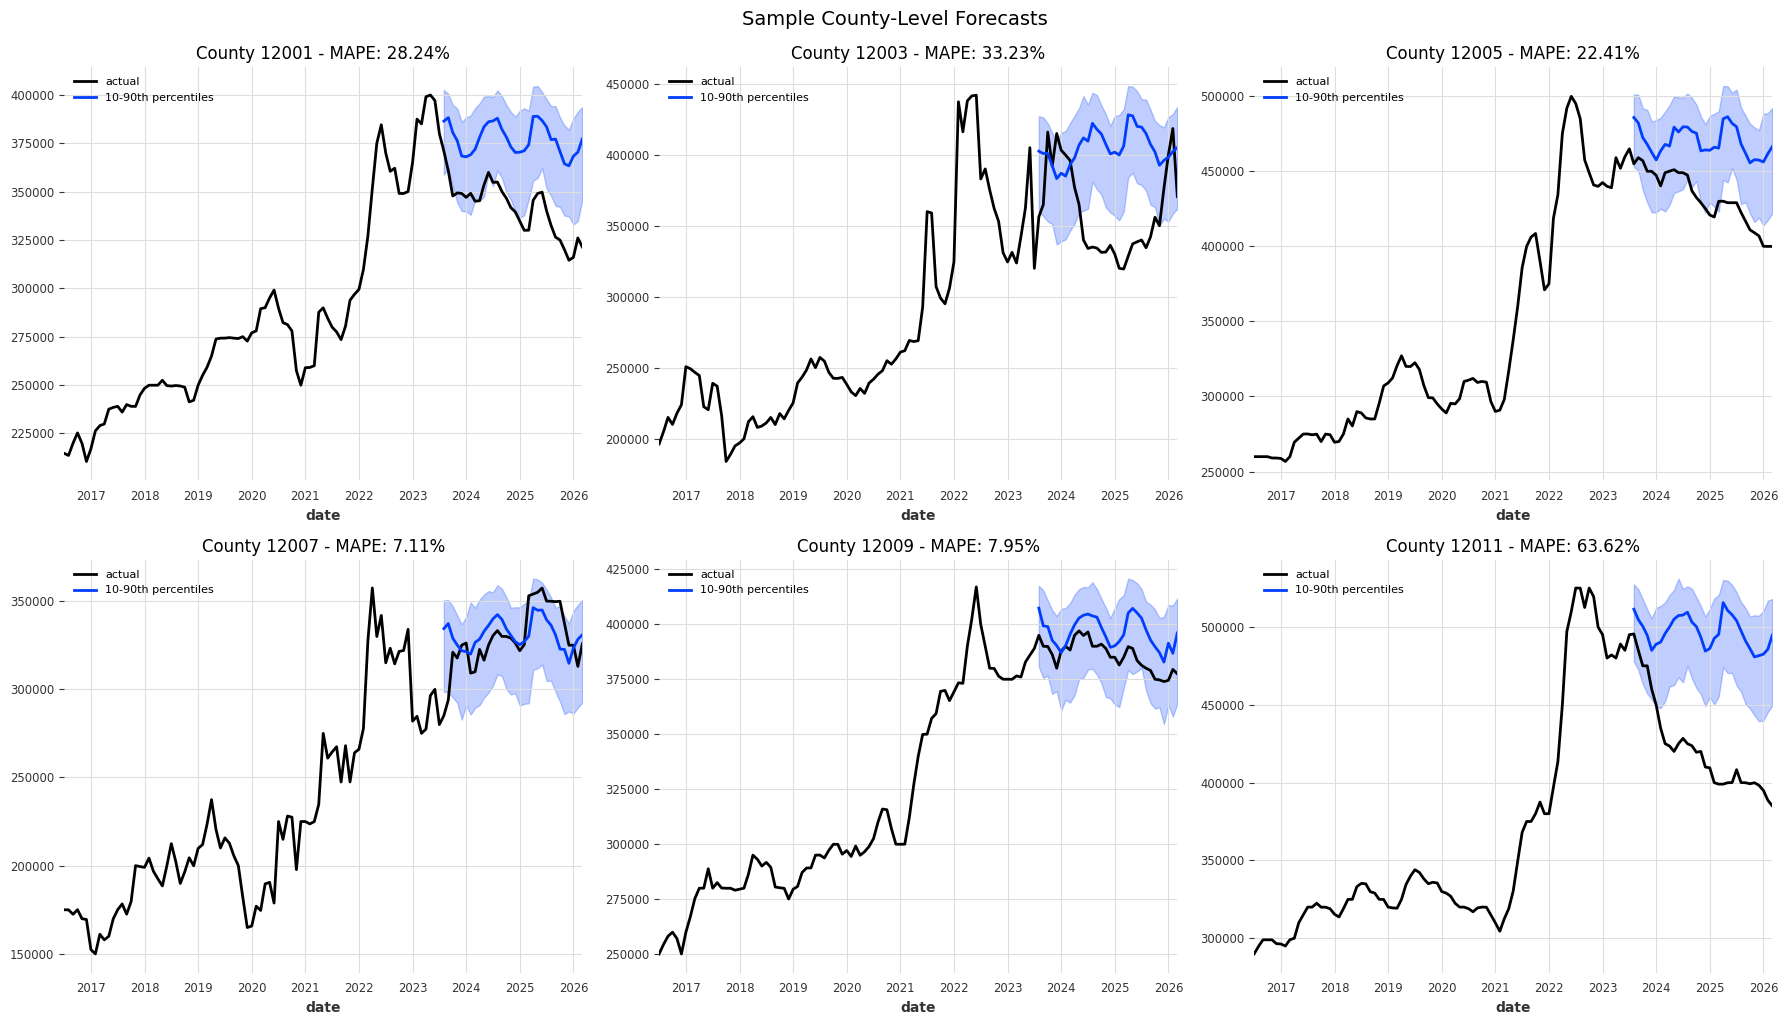

In [62]:
# Plot a few individual county forecasts for inspection
sample_fips = list(county_results.keys())[:6]  # first 6 counties

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, fips in zip(axes, sample_fips):
    data = county_results[fips]
    scaler = data['scaler_target']
    pred_inv = scaler.inverse_transform(county_preds[fips])
    actual_inv = scaler.inverse_transform(data['series_transformed'])
    
    plt.sca(ax)
    actual_inv[: pred_inv.end_time()].plot(label="actual")
    pred_inv.plot(low_quantile=low_q, high_quantile=high_q, label=label_q_inner)
    ax.set_title(f"County {fips} - MAPE: {county_mapes[fips]:.2f}%")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Sample County-Level Forecasts", y=1.02, fontsize=14)

In [56]:
# Backtest: historical forecasts across all counties
county_backtests = {}
for i, (fips, data) in enumerate(county_results.items()):
    bt = my_model.historical_forecasts(
        data['series_transformed'],
        future_covariates=data['future_cov_transformed'],
        past_covariates=data['past_cov_transformed'],
        start=data['train'].end_time() + data['train'].freq,
        num_samples=num_samples,
        forecast_horizon=forecast_horizon,
        stride=forecast_horizon,
        last_points_only=False,
        retrain=False,
        verbose=False,
    )
    county_backtests[fips] = bt
    if (i + 1) % 10 == 0:
        print(f"  Backtest complete for {i + 1}/{len(county_results)} counties")

print(f"Backtesting complete for {len(county_backtests)} counties.")

  Backtest complete for 10/51 counties
  Backtest complete for 20/51 counties
  Backtest complete for 30/51 counties
  Backtest complete for 40/51 counties
  Backtest complete for 50/51 counties
Backtesting complete for 51 counties.


In [57]:
# Save the county-level model and results
import pickle

save_data = {
    'model': my_model,
    'county_results': county_results,
    'county_mapes': county_mapes,
}

with open('../data/processed/tft_county_model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

print('County-level TFT model saved to ../data/processed/tft_county_model.pkl')

County-level TFT model saved to ../data/processed/tft_county_model.pkl
